In [ ]:
import sys
sys.path.append('../')
import joblib
from sklearn.exceptions import InconsistentVersionWarning
import warnings
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)
warnings.filterwarnings("ignore", category=UserWarning)
d = 3

In [22]:
BASE_FOLDER = f"imgs{d}"
dir = Path(f"../{BASE_FOLDER}")
dir.mkdir(exist_ok=True)
# Derive feature count from folder name
n_features = int(d)
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor = joblib.load(f"../data/processed/{n_features}features.pkl")
y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

# Rule based model relies on X1 which is not in the features, so we skip it here
xgboost = joblib.load(f'../models/xgboost_{n_features}features.pkl')
decision_tree = joblib.load(f'../models/decision_tree_{n_features}features.pkl')
knn = joblib.load(f'../models/knn_{n_features}features.pkl')
logistic_regression = joblib.load(f'../models/logreg_{n_features}features.pkl')
random_forest = joblib.load(f'../models/random_forest_{n_features}features.pkl')
gradient_boosting = joblib.load(f'../models/gradient_boosting_{n_features}features.pkl')
lightgbm = joblib.load(f'../models/lightgbm_{n_features}features.pkl')

models = {
    "XGBoost": xgboost,
    "Decision Tree": decision_tree,
    "KNN": knn,
    "LogReg": logistic_regression,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting,
    "LightGBM": lightgbm
}
# --- NEW BLOCK ADDED HERE ---
if n_features == 3:
    from src.rule_based import RuleBasedModel
    try:
        models["Rule Based"] = joblib.load(f'../models/rule_based.pkl')
    except ImportError:
        print("Warning: rule_based.py not found in path, skipping Rule Based model.")
# ----------------------------
results = []
predictions = {}
probabilities = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    y_prob = None
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "model") and hasattr(model.model, "predict_proba"):
        y_prob = model.model.predict_proba(X_test)[:, 1]
    probabilities[name] = y_prob
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        # Falls back to hard 0s and 1s if probabilities aren't available
        "ROC AUC": roc_auc_score(y_test, y_prob if y_prob is not None else y_pred),
        "PR AUC": average_precision_score(y_test, y_prob if y_prob is not None else y_pred)
    })
df_results = pd.DataFrame(results)

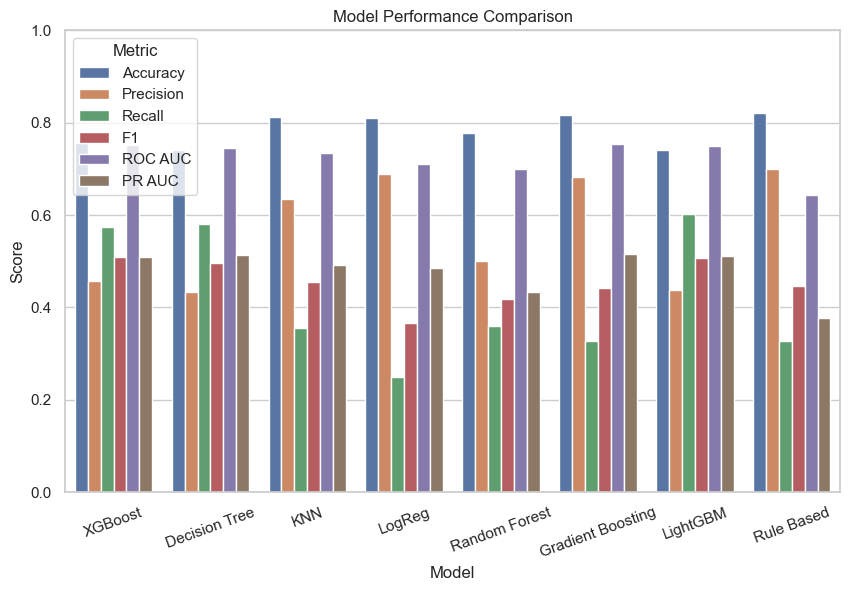

In [23]:
df_melted = df_results.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10,6))
sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric")

plt.title("Model Performance Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.savefig(f"../{BASE_FOLDER}/model_comparison_bar.png", bbox_inches="tight", dpi=300)
plt.show()

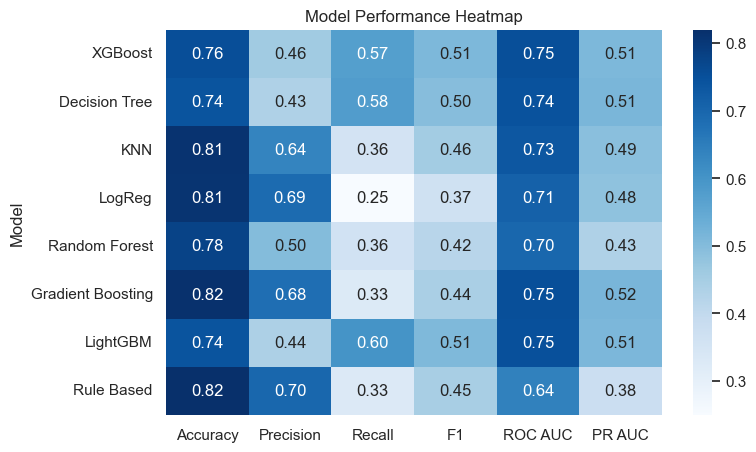

In [24]:
plt.figure(figsize=(8,5))
sns.heatmap(df_results.set_index("Model"), annot=True, fmt=".2f", cmap="Blues")

plt.title("Model Performance Heatmap")

plt.savefig(f"../{BASE_FOLDER}/model_comparison_heatmap.png", bbox_inches="tight", dpi=300)
plt.show()

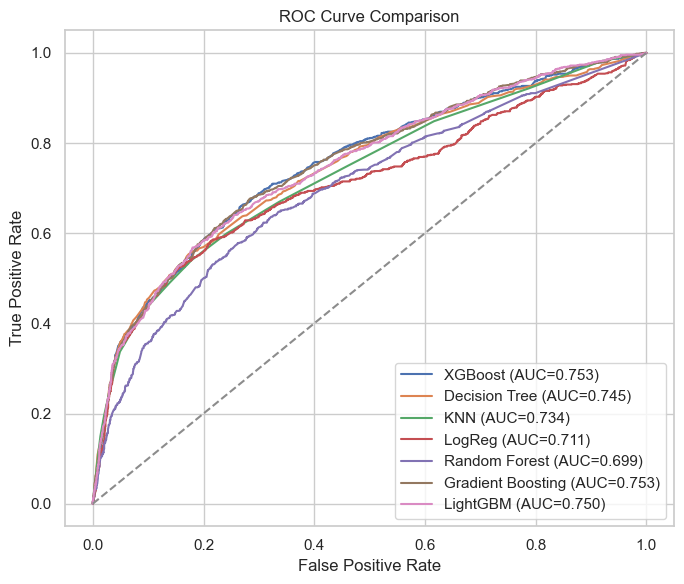

In [25]:
plt.figure(figsize=(7, 6))

for name, y_prob in probabilities.items():
    if y_prob is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(f"../{BASE_FOLDER}/roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

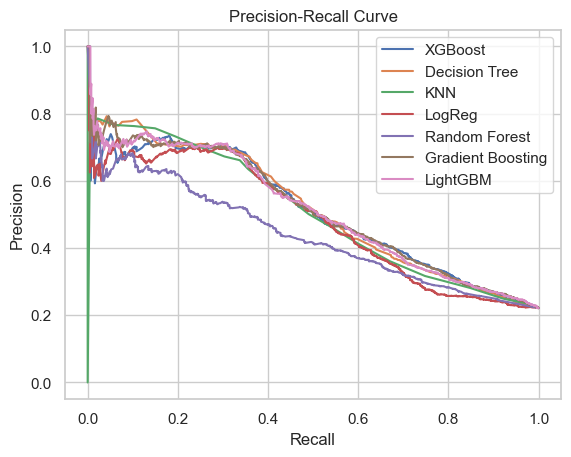

In [33]:
plt.figure()

for name, model in models.items():
    # Grab the pre-calculated probability from our dictionary instead of calling predict_proba
    probs = probabilities[name]
    
    # If a model truly has no probability scores, skip it so it doesn't crash the plot
    if probs is None:
        continue
        
    precision, recall, _ = precision_recall_curve(y_test, probs)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.savefig(f"../{BASE_FOLDER}/pr_curve.png", bbox_inches="tight", dpi=300)
plt.show()

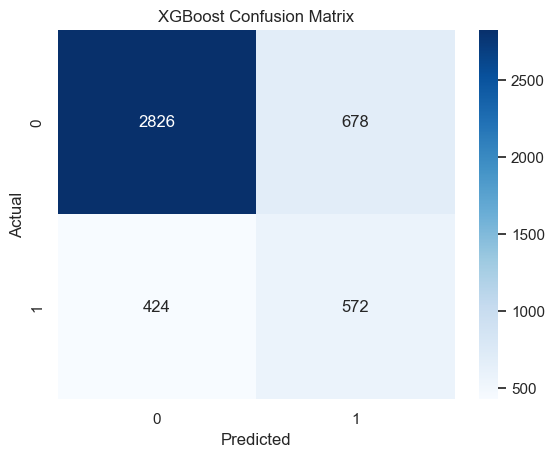

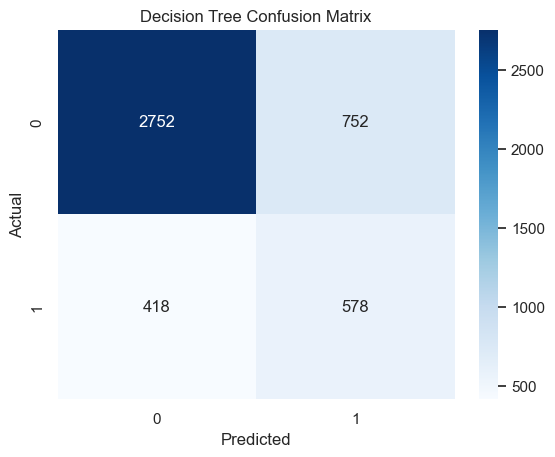

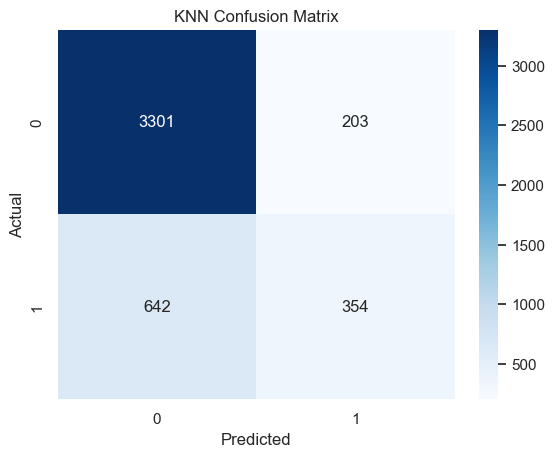

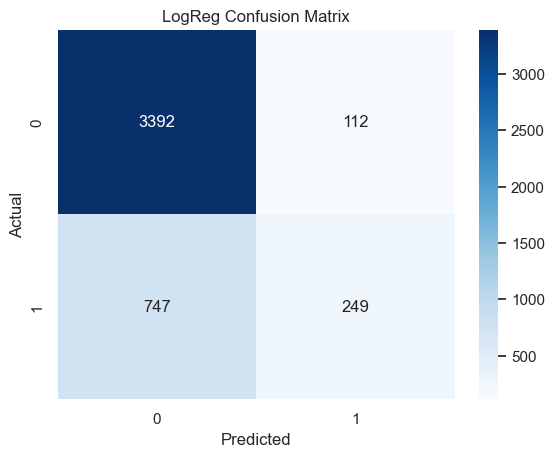

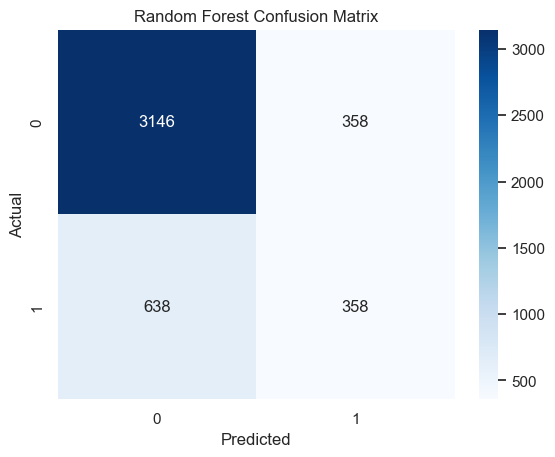

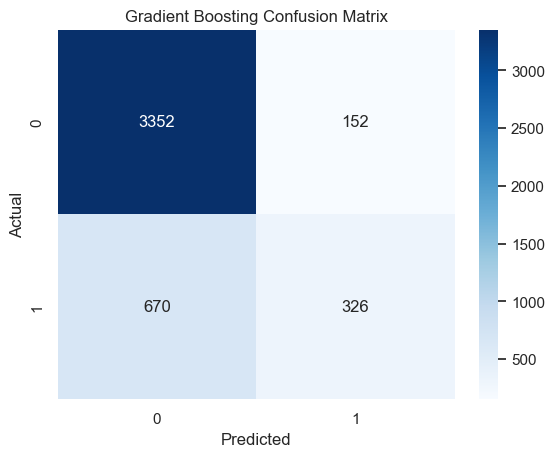

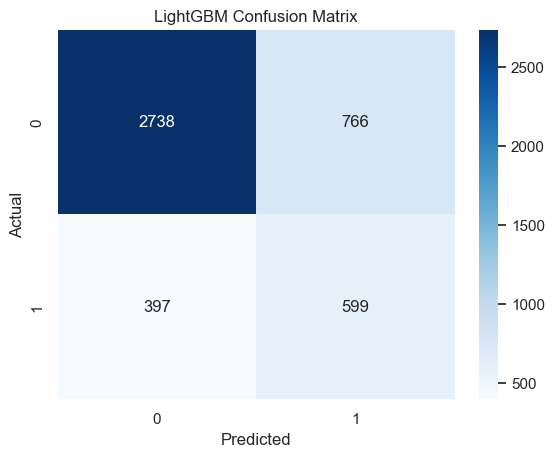

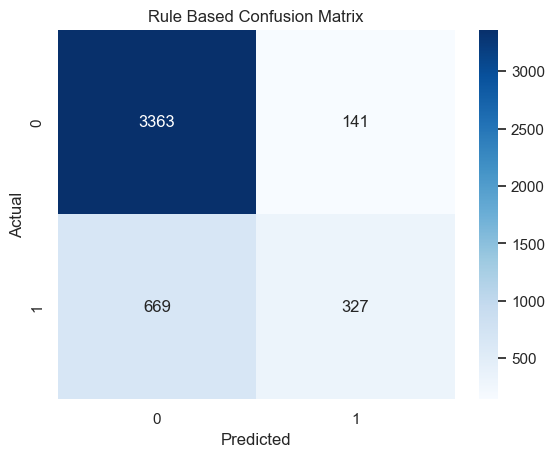

In [27]:
from sklearn.metrics import confusion_matrix

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.savefig(f"../{BASE_FOLDER}/cm_{name}.png", bbox_inches="tight", dpi=300)
    plt.show()

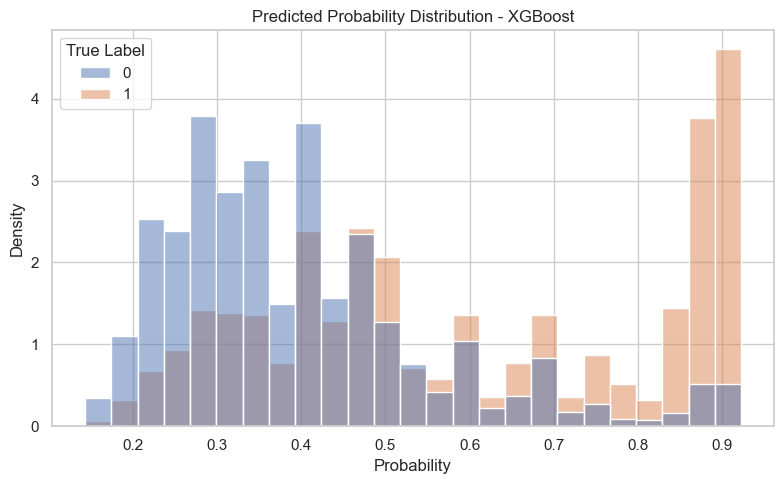

In [28]:
best_model_name = df_results.sort_values("F1", ascending=False).iloc[0]["Model"]
best_probs = probabilities[best_model_name]

if best_probs is not None:
    prob_df = pd.DataFrame({
        "Probability": best_probs,
        "True Label": y_test.astype(str)
    })

    plt.figure(figsize=(8, 5))
    sns.histplot(data=prob_df, x="Probability", hue="True Label", bins=25, stat="density", common_norm=False)
    plt.title(f"Predicted Probability Distribution - {best_model_name}")
    plt.tight_layout()
    plt.savefig(f"../{BASE_FOLDER}/best_model_probability_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

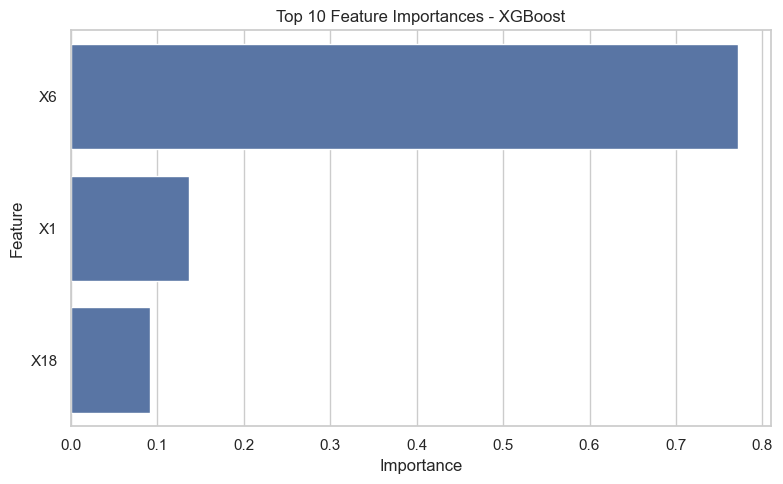

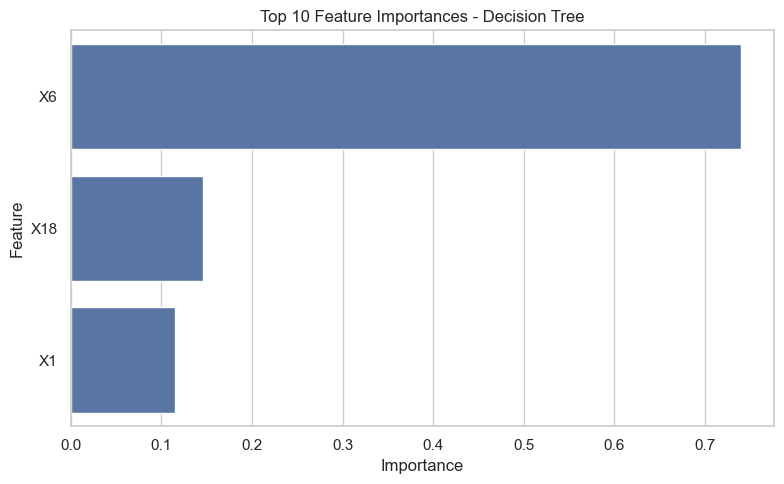

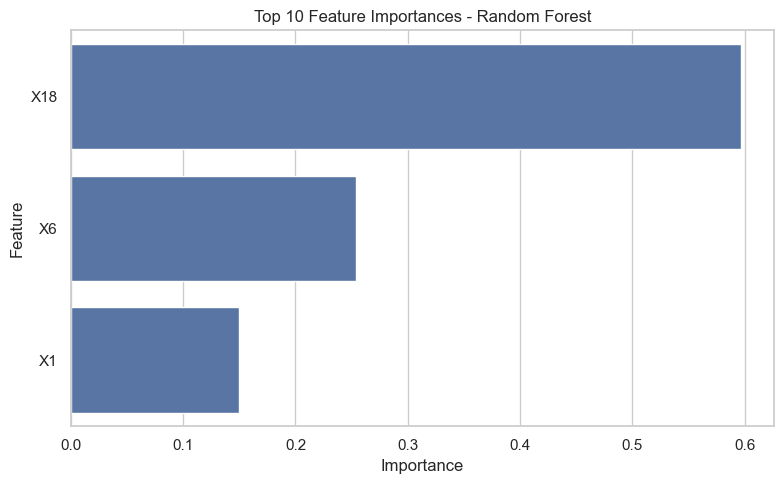

In [29]:
feature_names = X_test.columns if hasattr(X_test, "columns") else [f"Feature {i}" for i in range(X_test.shape[1])]

tree_models = {
    "XGBoost": xgboost,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest
}

for name, model in tree_models.items():
    
    if hasattr(model, "feature_importances_"):
        importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False).head(10)
        
        plt.figure(figsize=(8, 5))
        sns.barplot(x=importances.values, y=importances.index)
        plt.title(f"Top 10 Feature Importances - {name}")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.tight_layout()
        safe_name = name.lower().replace(" ", "_")
        plt.savefig(f"../{BASE_FOLDER}/feature_importance_{safe_name}.png", dpi=300, bbox_inches="tight")
        plt.show()

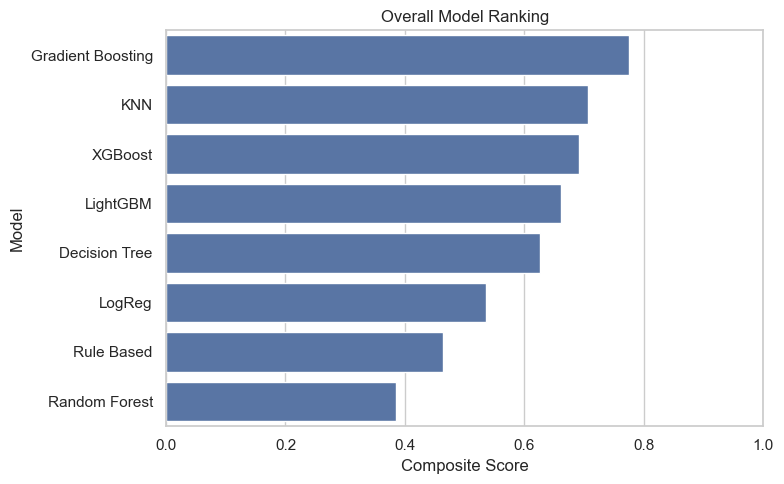

               Model  Composite Score
5  Gradient Boosting         0.775444
2                KNN         0.706089
0            XGBoost         0.691998
6           LightGBM         0.660818
1      Decision Tree         0.625961
3             LogReg         0.536264
7         Rule Based         0.463823
4      Random Forest         0.385485


In [30]:
df_rank = df_results.copy()

for col in ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "PR AUC"]:
    col_min = df_rank[col].min()
    col_max = df_rank[col].max()
    if pd.isna(col_min) or pd.isna(col_max) or col_max == col_min:
        df_rank[col + "_norm"] = 0
    else:
        df_rank[col + "_norm"] = (df_rank[col] - col_min) / (col_max - col_min)

norm_cols = [c for c in df_rank.columns if c.endswith("_norm")]
df_rank["Composite Score"] = df_rank[norm_cols].mean(axis=1)
df_rank = df_rank.sort_values("Composite Score", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=df_rank, x="Composite Score", y="Model")
plt.title("Overall Model Ranking")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(f"../{BASE_FOLDER}/model_composite_ranking.png", dpi=300, bbox_inches="tight")
plt.show()

print(df_rank[["Model", "Composite Score"]])

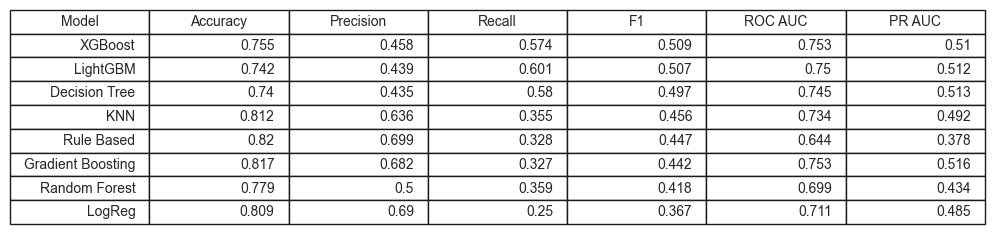

In [31]:
summary = df_results.copy().sort_values("F1", ascending=False)
summary_rounded = summary.copy()

for col in summary_rounded.columns[1:]:
    summary_rounded[col] = summary_rounded[col].round(3)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis("off")

table = ax.table(
    cellText=summary_rounded.values,
    colLabels=summary_rounded.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.15, 1.3)

plt.tight_layout()
plt.savefig(f"../{BASE_FOLDER}/model_summary_table.png", dpi=300, bbox_inches="tight")
plt.show()